# Поиск объявлений для Авито

По запросу и фильтрам нужно вернуть до 50 объявлений. В train известны положительные пары, полной разметки релевантности нет. Метрика задания, Recall@50, усредняется по запросам.

Сначала посмотрю, какие данные есть у запроса и объявления, как связаны строки train и что можно отложить для проверки качества.

In [1]:
from pathlib import Path
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import ROOT, SEARCH, SEED, corpus, labels, split_data
from src.text import normalize, stem_text, top
from src.ranking import recall_at_50, bootstrap

assert Path.cwd().resolve() == ROOT, "Запустите notebook из корня репозитория"
REBUILD = False  # пересчитать кандидатов, эмбеддинги и признаки
TRAIN = False  # заново обучить ранкеры
work = ROOT / "cache"
work.mkdir(exist_ok=True)
plt.rcParams.update({"figure.figsize": (7, 3.5), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

## Данные

In [2]:
import pyarrow.parquet as pq

schemas = {}
for name in ["train", "benchmark_items", "benchmark_queries"]:
    file = pq.ParquetFile(ROOT / "data" / f"{name}.parquet")
    schemas[name] = {field.name: str(field.type) for field in file.schema_arrow}
    print(name, file.metadata.num_rows, "строк")
pd.DataFrame(schemas).fillna("нет")

train 497673 строк
benchmark_items 189212 строк
benchmark_queries 2452 строк


,train,benchmark_items,benchmark_queries
search_query,string,нет,large_string
search_location_id,int64,нет,int64
search_is_delivery_search,int32,нет,int32
search_infm_params_text,string,нет,large_string
search_category,int64,нет,int64
item_title_raw,string,string,нет
item_rating_reviews_count,double,double,нет
item_rating,double,double,нет
item_price,"decimal128(27, 15)","decimal128(27, 15)",нет
item_microcat_id,int64,int64,нет


In [3]:
train = labels()
queries = pd.read_parquet(ROOT / "data/benchmark_queries.parquet")
items = corpus()
pd.Series({
    "строк train": len(train),
    "нормализованных текстов": train.query_norm.nunique(),
    "объявлений train": train.item_id.nunique(),
    "повторных положительных пар": train.duplicated(SEARCH + ["item_id"]).sum(),
    "объявлений в локальном каталоге": len(items),
    "запросов benchmark": len(queries),
}, name="Количество")

строк train                        497673
нормализованных текстов             73873
объявлений train                   344825
повторных положительных пар         30619
объявлений в локальном каталоге    515895
запросов benchmark                   2452
Name: Количество, dtype: int64

In [4]:
examples = train.drop_duplicates(SEARCH).head(6).merge(
    items[["item_id", "item_title_raw"]], on="item_id", validate="many_to_one")
examples[["search_query", "item_title_raw", "search_location_id", "item_location_id",
          "search_infm_params_text"]].rename(columns={
    "search_query": "запрос", "item_title_raw": "выбранное объявление",
    "search_location_id": "локация запроса", "item_location_id": "локация объявления",
    "search_infm_params_text": "фильтры"})

,запрос,выбранное объявление,локация запроса,локация объявления,фильтры
0,скупка телевизоров,скупка б/у техники,652430,652430,
1,автоподбор,автоподбор разовый осмотр автомобиля,640860,640860,Рейтинг пользователя 4 звезды и выше
2,баня на дровах,"баня на дровах ""прованс"" на цветочной",653240,653240,"Онлайн-запись Тип услуги СПА-услуги, массаж Ви..."
3,изготовление госномера на авто,"изготовление дубликатов авто номеров, гос номеров",634670,633570,"Вид услуги Оборудование, производство"
4,укладка плитки,ремонт и отделка квартир под ключ,658430,658430,Тип услуги Ремонт квартир и домов под ключ Вид...
5,сборка мебели,сборка мебели,639550,637770,Тип услуги Сборка и ремонт мебели Вид услуги Р...


In [5]:
raw_nulls = {}
for name in ["train", "benchmark_items"]:
    counts = pd.Series(0, index=schemas[name], dtype="int64")
    for batch in pq.ParquetFile(ROOT / "data" / f"{name}.parquet").iter_batches(batch_size=8192):
        counts += pd.Series({name: col.null_count for name, col in zip(batch.schema.names, batch.columns)})
    raw_nulls[name] = counts
quality = pd.DataFrame(raw_nulls).fillna(0).astype(int)
quality[quality.sum(axis=1).gt(0)]

,train,benchmark_items
item_description_raw,0,35
item_latitude,4,1
item_longitude,4,1
item_rating,28232,17631
item_rating_reviews_count,19211,11615


In [6]:
raw_catalogue = pd.read_parquet(
    ROOT / "data/benchmark_items.parquet", columns=["item_id", "item_location_id"])
display(pd.Series({
    "повторных item_id в исходном benchmark": raw_catalogue.item_id.duplicated().sum(),
    "пустых заголовков после заполнения пропусков": items.item_title_raw.eq("").sum(),
    "пустых описаний после заполнения пропусков": items.item_description_raw.eq("").sum(),
    "отрицательное число отзывов": items.item_rating_reviews_count.lt(0).sum(),
    "рейтинг вне [0, 5]": (items.item_rating.lt(0) | items.item_rating.gt(5)).sum(),
    "локации запроса нет в benchmark":
        (~queries.search_location_id.isin(raw_catalogue.item_location_id)).sum(),
}, name="Количество"))
assert items.item_id.is_unique
seen_share = queries.search_query.map(normalize).isin(train.query_norm).mean()
print(f"В train встречалось {seen_share:.1%} текстов benchmark")
del raw_catalogue

повторных item_id в исходном benchmark            0
пустых заголовков после заполнения пропусков      0
пустых описаний после заполнения пропусков       35
отрицательное число отзывов                       0
рейтинг вне [0, 5]                                0
локации запроса нет в benchmark                 427
Name: Количество, dtype: int64

В train встречалось 37.4% текстов benchmark


`train` состоит из положительных пар. Один текст встречается с разными фильтрами и объявлениями, поэтому повторы item_id здесь ожидаемы. Для локальной проверки объединяю уникальные объявления train и benchmark, при совпадении ID беру метаданные benchmark.

Текстовые пропуски заменяю пустыми строками, неизвестный рейтинг оставляю как NaN. У части запросов код локации отсутствует в каталоге. Жёсткий фильтр по этому коду оставил бы их без ответа.

In [7]:
train_items = train.drop_duplicates("item_id")
benchmark_meta = pd.read_parquet(ROOT / "data/benchmark_items.parquet",
                                 columns=["item_category_id", "item_microcat_id"])
display(pd.DataFrame({
    "train": train_items[["item_category_id", "item_microcat_id"]].nunique(),
    "benchmark": benchmark_meta.nunique(),
}).rename(index={"item_category_id": "категорий", "item_microcat_id": "микрокатегорий"}))
category_share = pd.DataFrame({
    "train": train_items.item_category_id.value_counts(normalize=True),
    "benchmark": benchmark_meta.item_category_id.value_counts(normalize=True),
}).fillna(0).sort_values("benchmark", ascending=False)
display(category_share.head(8).round(3))
del train_items, benchmark_meta

,train,benchmark
категорий,8,47
микрокатегорий,212,752


,train,benchmark
item_category_id,,
114,1.0,0.990
19,0.0,0.002
112,0.0,0.001
40,0.0,0.001
33,0.0,0.001
10,0.0,0.001
20,0.0,0.000
25,0.0,0.000


В benchmark больше редких категорий, хотя в обоих каталогах почти всё относится к услугам. Это повод использовать категорию как сигнал, но не отсеивать остальные объявления до проверки качества.

## Локальная проверка

При случайном split строк одинаковые запросы попадут и в обучение, и в проверку. Отложу 800 нормализованных текстов для val и ещё 800 для test. Это проверка на новых формулировках. У каждого текста выберу один контекст поиска, его известные позитивы составят `gold`.

Recall@50 считаю как `|answer ∩ gold| / |gold|`. Пропущенные поиском позитивы остаются в знаменателе. Порядок внутри первых 50 на метрику не влияет. Параметры буду выбирать по val, test оставлю для сравнения после выбора.

In [8]:
first, fit_first, _ = split_data(train, 20260927, (), training=False)
first_val = np.flatnonzero(first.split.eq("val"))
first_test = np.flatnonzero(first.split.eq("test"))
item_ids = items.item_id.to_numpy()
assert not set(fit_first.query_norm) & set(first.query_norm)
assert not set(first.iloc[first_val].query_norm) & set(first.iloc[first_test].query_norm)
catalogue_ids = set(item_ids)
assert all(set(gold) <= catalogue_ids for gold in first.gold)
first.gold.map(len).value_counts().sort_index().rename("число запросов")

gold
1    1530
2      59
3       6
4       4
6       1
Name: число запросов, dtype: int64

У большинства запросов один известный позитив, но несколько тоже встречаются. Поэтому считаю долю найденных позитивов, а не только факт попадания.

Объявления могут повторяться между обучением и проверкой, поиск идёт в известном каталоге. Его тексты доступны без разметки релевантности, их можно использовать для словаря и IDF. Статистику по положительным парам считаю только на обучении. Дат для временного разделения нет.

## Бейзлайн

Начну с BM25. В текст объявления включу заголовок три раза, параметры и первые 2000 символов описания. Так заголовок получит больший вес. Сначала посмотрю выдачу для одного запроса на небольшом фрагменте каталога. Это пример работы поиска, метрику ниже считаю на полном каталоге.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
from src.text import bm25

example = train.iloc[0]
example_items = pd.concat([
    items.sample(3000, random_state=SEED),
    items[items.item_id.eq(example.item_id)],
]).drop_duplicates("item_id")
documents = (example_items.item_title_raw + " " + example_items.item_title_raw + " " +
             example_items.item_title_raw + " " + example_items.item_infm_params_text + " " +
             example_items.item_description_raw)
vectorizer = CountVectorizer(dtype=np.float32)
index = bm25(vectorizer.fit_transform(documents))
query = vectorizer.transform([normalize(example.search_query)])
query.data[:] = 1
scores = (query @ index).toarray().ravel()
nearest = top(scores, 5)
print(example.search_query)
display(pd.DataFrame({"объявление": example_items.iloc[nearest].item_title_raw.to_numpy(),
                      "BM25": scores[nearest],
                      "известный позитив": example_items.iloc[nearest].item_id.eq(example.item_id).to_numpy()}))
del example_items, documents, vectorizer, index, query, scores

скупка телевизоров


,объявление,BM25,известный позитив
0,"скупка телевизоров,ноутбуков,компьютеров",18.510269,False
1,скупка цифровой техники,15.014708,False
2,ремонт телевизоров любых моделей,11.217813,False
3,ремонт телевизоров на дому / частный мастер,10.899065,False
4,ремонт телевизоров на дому / замена подствеки ...,10.802481,False


Для первой метрики оставлю небольшой бонус совпадению локации, 1.15, без подбора. Расчёт по всем отложенным запросам вынесен в `collect`. Сохранённые кандидаты позволяют дальше менять веса без повторного умножения разреженных матриц.

In [10]:
from src.retrieval import cached_collect, search


def measure(predictions, queries):
    return np.array([recall_at_50(item_ids[p], gold)
                     for p, gold in zip(predictions, queries.gold)])


def search_recall(queries, candidates, config, indices, prior=None, geo=None):
    predictions = search(items, queries, candidates, config, indices, prior, geo)
    return measure(predictions, queries.iloc[indices])

In [11]:
candidates = {"word": cached_collect(items, first, "word", work / "search",
                                     bundle=ROOT / "artifacts/search", rebuild=REBUILD)}
settings = {"BM25": {"channels": {"word": 1}, "location": 1.15, "service": 1}}
base_val = search_recall(first, candidates, settings["BM25"], first_val)
print(f"Текстовый поиск, val Recall@50 = {base_val.mean():.4f}")

Текстовый поиск, val Recall@50 = 0.3719


BM25 сопоставляет токены буквально. Стемминг позволит искать разные формы одного слова как один токен.

In [12]:
words = ["сварщик", "сварщики", "ремонт", "ремонта", "канализация", "канализации"]
display(pd.DataFrame({"слово": words, "после стемминга": list(map(stem_text, words))}))
candidates["stem"] = cached_collect(items, first, "stem", work / "search",
                                     bundle=ROOT / "artifacts/search", rebuild=REBUILD)
settings["Стемминг"] = {**settings["BM25"], "channels": {"stem": 1}}
stem_val = search_recall(first, candidates, settings["Стемминг"], first_val)
print(f"Со стеммингом, val Recall@50 = {stem_val.mean():.4f}")

,слово,после стемминга
0,сварщик,сварщик
1,сварщики,сварщик
2,ремонт,ремонт
3,ремонта,ремонт
4,канализация,канализац
5,канализации,канализац


Со стеммингом, val Recall@50 = 0.4269


Совпадение локации пока почти не влияет на выдачу. Подберу его вес и общий бонус категории услуг по val.

Для этого в сохранённом поиске есть top-500 по тексту и до 100 объявлений из каждой комбинации совпадения локации и категории услуг. Внутри такой группы множитель одинаков, её top-100 достаточно для общего top-50.

In [13]:
from itertools import product

grid = []
for location, service in product([1, 1.15, 2, 4, 8, 16, 32, 64], [1, 2, 4]):
    config = {"channels": {"stem": 1}, "location": location, "service": service}
    score = search_recall(first, candidates, config, first_val).mean()
    grid.append({**config, "val": score})
chosen = max(grid, key=lambda row: row["val"])
settings["Локация"] = {k: v for k, v in chosen.items() if k != "val"}
pd.DataFrame(grid).drop(columns="channels").sort_values("val", ascending=False).head(5)

,location,service,val
23,64.0,4,0.696146
22,64.0,2,0.696146
21,64.0,1,0.696146
20,32.0,4,0.696146
19,32.0,2,0.696146


Следующая гипотеза связана с частями слов и вариантами написания. Добавлю символьный TF-IDF по заголовкам. У BM25 и TF-IDF разные масштабы оценок, поэтому смешаю их по рангам.

Для кандидата сумма равна `1 / (60 + ранг BM25) + вес / (60 + ранг TF-IDF)`. Оценки перед ранжированием уже учитывают выбранные бонусы локации и услуг.

In [14]:
candidates["char"] = cached_collect(items, first, "char", work / "search",
                                     bundle=ROOT / "artifacts/search", rebuild=REBUILD)
grid = []
for location, weight in product([2, 4, 8, 16, 32], [0.25, 0.5, 1, 2]):
    config = {**settings["Локация"], "location": location,
              "channels": {"stem": 1, "char": weight}}
    grid.append({"config": config,
                 "val": search_recall(first, candidates, config, first_val).mean()})
chosen = max(grid, key=lambda row: row["val"])
settings["Символьный поиск"] = chosen["config"]
print(settings["Символьный поиск"])
print(f"val Recall@50 = {chosen['val']:.4f}")

{'channels': {'stem': 1, 'char': 0.5}, 'location': 8, 'service': 1}
val Recall@50 = 0.7133


Похожие запросы могут указывать на одну микрокатегорию даже при слабом совпадении слов с объявлением. Использую десять ближайших обучающих текстов по символьному TF-IDF с n-граммами 2-5.

Распределение категорий каждого соседа нормировано, вес соседа равен квадрату косинуса. Сходство ниже 0.2 обнуляется. Отложенные тексты в расчёт этого сигнала не входят.

In [15]:
from src.pipeline import prior_probabilities

prior_first = prior_probabilities(fit_first, first)
grid = []
for weight in [0.25, 0.5, 1, 2, 4]:
    config = {**settings["Символьный поиск"], "prior": weight}
    score = search_recall(first, candidates, config, first_val, prior_first).mean()
    grid.append({"config": config, "val": score})
chosen = max(grid, key=lambda row: row["val"])
settings["Вероятность категории"] = chosen["config"]
print(f"Вес категории {chosen['config']['prior']}, val Recall@50 = {chosen['val']:.4f}")

Вес категории 0.5, val Recall@50 = 0.7221


In [16]:
lexical_scores = {}
for name, config in settings.items():
    lexical_scores[name] = {
        split: search_recall(first, candidates, config, indices, prior_first)
        for split, indices in [("val", first_val), ("test", first_test)]
    }
lexical_table = pd.DataFrame({name: {split: values.mean() for split, values in scores.items()}
                              for name, scores in lexical_scores.items()}).T
print("Проверка текстового поиска")
lexical_table.round(4)

Проверка текстового поиска


,val,test
BM25,0.3719,0.3703
Стемминг,0.4269,0.4607
Локация,0.6961,0.7183
Символьный поиск,0.7133,0.7164
Вероятность категории,0.7221,0.7339


В показанном запуске география дала самый большой прирост. Символьный поиск помог на val, но отдельно не прибавил на test. Посмотрю срез запросов, для которых совпадение кода локации невозможно.

In [17]:
present = first.iloc[first_val].search_location_id.isin(items.item_location_id).to_numpy()
pd.DataFrame({"локация есть в каталоге": present,
              "Recall@50": lexical_scores["Вероятность категории"]["val"]}).groupby(
                  "локация есть в каталоге")["Recall@50"].agg(["count", "mean"]).round(4)

,count,mean
локация есть в каталоге,,
False,136,0.4375
True,664,0.7804


## География и размер набора кандидатов

Без точного совпадения локации Recall заметно ниже. Проверю, помогает ли статистика переходов из локации запроса в локацию положительного объявления. Каждая пара «текст запроса, локация поиска» в сумме получает вес 1, независимо от числа позитивов. Частоты переходов нормирую, а для редких исходных локаций уменьшаю поправку.

Первый test уже просмотрен. Для следующего сравнения отложу новые 800 val и 800 test, исключив тексты первой проверки. На этом разбиении снова посчитаю исходный вариант, поскольку метрики разных выборок напрямую сравнивать нельзя.

In [18]:
from src.geography import GeoModel

geo_queries, fit_geo, _ = split_data(train, 2026092705, (20260927,), training=False)
assert not set(geo_queries.query_norm) & set(first.query_norm)
geo = GeoModel.fit(fit_geo)
prior_geo = prior_probabilities(fit_geo, geo_queries)
geo_val = np.flatnonzero(geo_queries.split.eq("val"))
geo_test = np.flatnonzero(geo_queries.split.eq("test"))
geo_base = {channel: cached_collect(items, geo_queries, channel, work / "geography",
                                    bundle=ROOT / "artifacts/geography", rebuild=REBUILD, suffix="_base")
            for channel in ["stem", "char"]}
source = geo_queries.search_location_id.iloc[0]
signal = geo.signal(source, alpha=5, beta=0)
shown = top(signal[:-1], 5)
pd.DataFrame({"локация запроса": source, "локация объявления": geo.destinations[shown],
              "поправка": signal[shown]})

,локация запроса,локация объявления,поправка
0,661420,661420,0.998546
1,661420,654070,0.004303
2,661420,637640,0.002171
3,661420,661010,0.001918
4,661420,661130,0.001404


К выбранному бонусу совпадения локации добавлю частотную поправку. Подбираю её силу, сглаживание редких локаций и применение ко всем запросам либо только к запросам без точного совпадения. Ещё один вариант делит частоту перехода на популярность локации назначения.

In [19]:
base_config = dict(settings["Вероятность категории"])
geo_grid = []
for alpha, beta, strength, scope in product([5, 20], [0, 0.5], [8, 32, 128], ["all", "missing"]):
    config = {**base_config, "alpha": alpha, "beta": beta,
              "geo_strength": strength, "scope": scope}
    score = search_recall(geo_queries, geo_base, config, geo_val, prior_geo, geo).mean()
    geo_grid.append({"config": config, "val": score})
chosen = max(geo_grid, key=lambda row: row["val"])
geo_config = chosen["config"]
print({key: geo_config[key] for key in ["alpha", "beta", "geo_strength", "scope"]})
print(f"val Recall@50 = {chosen['val']:.4f}")

{'alpha': 5, 'beta': 0, 'geo_strength': 128, 'scope': 'all'}
val Recall@50 = 0.7502


Переоценка не вернёт объявление, которого уже нет среди кандидатов. Добавлю top-500 после применения географии. Для контроля сделаю такое же расширение только с бонусом точного совпадения.

In [20]:
exact_config = {**geo_config, "geo_strength": 0}
expanded = {
    name: {channel: cached_collect(items, geo_queries, channel, work / "geography",
                                   bundle=ROOT / "artifacts/geography", rebuild=REBUILD,
                                   geo=geo, config=config, suffix=f"_{name}")
           for channel in ["stem", "char"]}
    for name, config in [("location", exact_config), ("learned", geo_config)]
}
variants = {
    "Только совпадение локации": (geo_base, exact_config),
    "То же с расширением": (expanded["location"], exact_config),
    "Обученная география": (geo_base, geo_config),
    "География с расширением": (expanded["learned"], geo_config),
}
geo_scores = {name: search_recall(geo_queries, found, config, geo_val, prior_geo, geo)
              for name, (found, config) in variants.items()}
geo_choice = max(["Обученная география", "География с расширением"],
                 key=lambda name: geo_scores[name].mean())
print("Выбор по val", geo_choice)

Выбор по val Обученная география


In [21]:
geo_rows = []
for name, (found, config) in variants.items():
    scores = search_recall(geo_queries, found, config, geo_test, prior_geo, geo)
    coverage = []
    for i in geo_test:
        ids = np.unique(np.concatenate([
            ids[i, (ids[i] >= 0) & (scores[i] > 0)] for ids, scores in found.values()]))
        gold = set(geo_queries.iloc[i].gold)
        coverage.append(len(set(item_ids[ids]) & gold) / len(gold))
    geo_rows.append({"вариант": name, "val": geo_scores[name].mean(),
                     "test": scores.mean(), "покрытие кандидатов на test": np.mean(coverage)})
geo_table = pd.DataFrame(geo_rows).set_index("вариант")
print("Проверка географии")
geo_table.round(4)

Проверка географии


,val,test,покрытие кандидатов на test
вариант,,,
Только совпадение локации,0.7048,0.7238,0.8612
То же с расширением,0.7035,0.7225,0.8931
Обученная география,0.7502,0.7481,0.8612
География с расширением,0.7479,0.7575,0.9375


В сохранённом запуске расширение проиграло переоценке по val, хотя заметно увеличило покрытие кандидатов. Для текущей поисковой формулы оно не подошло. Но найденные дополнительно позитивы дают повод попробовать другой отбор.

Следующее сравнение проверит ранкер на расширенном наборе. В него передаю выбранные выше веса каналов, категории и географии.

In [22]:
del candidates, expanded, geo_base, variants, prior_first, prior_geo, geo, fit_first, fit_geo

_ = gc.collect()

## Обучаемый отбор

Для первого ранкера возьму оценки и позиции поисковых каналов, географию, вероятность микрокатегории, рейтинг, отзывы и признаки запроса. Всего 35 признаков. ID и частоту объявления среди позитивов не использую. Цену и координаты пока оставлю в стороне, их польза здесь не проверялась.

География и категории используют разметку. Для обучающих запросов посчитаю их по двум другим фолдам. Возьму по 2000 запросов из каждого из трёх фолдов. Вместе с ограничением числа негативов это удерживает обучение около миллиона строк. Это рабочий бюджет для CPU, оптимальность числа 6000 отдельно не проверялась.

Для сравнения ранкеров отложу новые 800 val и 800 test, исключив тексты прежних проверок.

In [23]:
text_seed = 2026092806
text_queries, fit_text, text_blocks = split_data(train, text_seed, (20260927, 2026092705))
assert set(text_queries.query_norm).isdisjoint(set(first.query_norm) | set(geo_queries.query_norm))

text_val = np.flatnonzero(text_queries.split.eq("val"))
text_test = np.flatnonzero(text_queries.split.eq("test"))

fold_rows = []
for i, (q, fitting) in enumerate(text_blocks):
    assert not set(q.query_norm) & set(fitting.query_norm)
    assert not set(fitting.query_norm) & set(text_queries.query_norm)
    fold_rows.append({"фолд": i, "запросов ранкера": len(q),
                      "текстов для географии и категорий": fitting.query_norm.nunique()})
pd.DataFrame(fold_rows)

,фолд,запросов ранкера,текстов для географии и категорий
0,0,2000,46048
1,1,2000,46049
2,2,2000,46049


In [24]:
from src.pipeline import prepare_core, add_fields
from src.features import CORE_NAMES, FIELD_NAMES, FEATURE_NAMES

text_train = [prepare_core(items, q, fitting, geo_config,
                           work / f"training/text_ranker/fold{fold}",
                           bundle=ROOT / f"artifacts/training/text_ranker/fold{fold}",
                           rebuild=REBUILD, training=True, seed=text_seed, fold=fold)
              for fold, (q, fitting) in enumerate(text_blocks)]
text_features = prepare_core(items, text_queries, fit_text, geo_config, work / "text_ranker",
                             bundle=ROOT / "artifacts/text_ranker", rebuild=REBUILD)
assert all(block["X"].shape[1] == len(CORE_NAMES) == 35 for block in text_train)
print("Признаков первого ранкера", text_features["X"].shape[1])

Признаков первого ранкера 35


Негативы беру из найденных кандидатов, до 128 с высоким поисковым баллом и до 64 случайных. Из них исключены все известные позитивы того же текста, даже если они относятся к другому контексту. Группы без найденного позитива пропускаются при обучении, но остаются при оценке Recall.

CatBoost оптимизирует PairLogit внутри запросов. Сумма весов пар одного запроса равна 192, поэтому запрос с несколькими позитивами не получает лишний вес.

In [25]:
training_rows = []
for arrays, (q, _) in zip(text_train, text_blocks):
    sizes = np.diff(arrays["offsets"])
    for i, row in enumerate(q.itertuples()):
        lo, hi = arrays["offsets"][i:i + 2]
        ids = item_ids[arrays["ids"][lo:hi]]
        y = arrays["y"][lo:hi]
        assert not set(ids[y == 0]) & set(row.known_positives)
        assert set(ids[y == 1]) <= set(row.gold)
    training_rows.append({"запросов": len(q), "с найденным позитивом": (sizes > 0).sum(),
                          "строк": len(arrays["y"]), "позитивов": int(arrays["y"].sum())})
pd.DataFrame(training_rows).sum().rename("обучение")

запросов                    6000
с найденным позитивом       5653
строк                    1091377
позитивов                   6001
Name: обучение, dtype: int64

In [26]:
from src.ranking import fit_ranker

params = dict(loss_function="PairLogit", iterations=500, depth=6, learning_rate=0.05,
              l2_leaf_reg=5, thread_count=6, allow_writing_files=False, verbose=100)
core_model = fit_ranker(text_train, work / "model/text_35.cbm", ROOT / "model/text_35.cbm",
                        {**params, "random_seed": text_seed}, train=TRAIN)
text_models = {"35 признаков": core_model}

Проверю число деревьев и смешивание с поисковой оценкой. При весе 1 работает только CatBoost, при 0.5 поисковый и модельный ранги имеют равный вес. Это позволяет сохранить сильный сигнал поиска при небольшом обучении.

In [27]:
from src.pipeline import predict


def evaluate_ranker(features, model, queries, split, trees, weight):
    indices = np.flatnonzero(queries.split.eq(split))
    predictions = predict(features, model, trees, weight, indices=indices)
    return measure(predictions, queries.iloc[indices]), predictions


text_grid = []
for trees, weight in product([100, 250, 500], [0.5, 0.75, 1.0]):
    scores, _ = evaluate_ranker(text_features, core_model, text_queries, "val", trees, weight)
    text_grid.append({"модель": "35 признаков", "деревьев": trees, "вес": weight, "val": scores.mean()})
pd.DataFrame(text_grid).pivot(index="деревьев", columns="вес", values="val").round(4)

вес,0.50,0.75,1.00
деревьев,,,
100,0.8134,0.7838,0.7551
250,0.8178,0.7786,0.7424
500,0.8109,0.7634,0.7280


Общий поисковый балл не различает, где совпали слова. Добавлю 22 признака по заголовку, параметрам и описанию. Для каждого поля это BM25, доля покрытых слов, длина и вхождение фразы. Ещё проверяются фильтры, рейтинг и числа. Кандидаты и обучающие пары остаются прежними.

In [28]:
text_train = [add_fields(block, items, q, rebuild=REBUILD)
              for block, (q, _) in zip(text_train, text_blocks)]
text_features = add_fields(text_features, items, text_queries, rebuild=REBUILD)
assert text_features["X"].shape[1] == len(CORE_NAMES) + len(FIELD_NAMES) == 57

# Один запрос и признаки его первых поисковых кандидатов.
i = text_val[0]
a, b = text_features["offsets"][i:i + 2]
rows = a + top(text_features["rrf"][a:b], 4)
print(text_queries.iloc[i].search_query)
columns = ["title_query_coverage", "description_query_coverage", "same_location", "prior_relative"]
feature_view = pd.DataFrame(text_features["X"][rows][:, [FEATURE_NAMES.index(name) for name in columns]],
                            columns=["покрытие заголовка", "покрытие описания", "та же локация", "категория"])
feature_view.insert(0, "объявление", items.iloc[text_features["ids"][rows]].item_title_raw.to_numpy())
feature_view.round(3)

3d печать изделия из абс пластика на заказ


,объявление,покрытие заголовка,покрытие описания,та же локация,категория
0,печать пластиком на заказ на 3d принтере,0.625,0.250,1.0,1.0
1,fdm 3d печать на заказ,0.500,0.750,1.0,1.0
2,3d печать,0.250,0.875,1.0,1.0
3,"3d печать пластиком, фотополимерная 3d печать, 3d",0.375,0.875,1.0,1.0


In [29]:
fields_model = fit_ranker(text_train, work / "model/text_57.cbm", ROOT / "model/text_57.cbm",
                          {**params, "random_seed": text_seed}, train=TRAIN)
text_models["57 признаков"] = fields_model
for trees, weight in product([100, 250, 500], [0.5, 0.75, 1.0]):
    scores, _ = evaluate_ranker(text_features, fields_model, text_queries, "val", trees, weight)
    text_grid.append({"модель": "57 признаков", "деревьев": trees, "вес": weight, "val": scores.mean()})
text_grid = pd.DataFrame(text_grid)
text_choices = text_grid.loc[text_grid.groupby("модель", sort=False).val.idxmax()].set_index("модель")
from src.ranking import save_choice

for name, filename in [("35 признаков", "text_35"), ("57 признаков", "text_57")]:
    choice = text_choices.loc[name]
    save_choice(text_models[name], work / f"model/{filename}.cbm",
                choice["деревьев"], choice["вес"], geo_config,
                semantic=False, split_name="text_ranker")
text_choices.round(4)

,деревьев,вес,val
модель,,,
35 признаков,250,0.5,0.8178
57 признаков,500,0.5,0.8270


Настройки выбраны по val. На test сравню эти варианты и отдельно модели без смешивания при одинаковых 500 деревьях. Второе сравнение отделяет признаки от смены настроек.

In [30]:
text_scores = {}
text_rows = []
for name, model in text_models.items():
    choice = text_choices.loc[name]
    for label, trees, weight in [(name, int(choice["деревьев"]), choice["вес"]),
                                 (f"{name}, без смешивания", 500, 1.0)]:
        score, _ = evaluate_ranker(text_features, model, text_queries, "test", trees, weight)
        text_scores[label] = score
        val_score = text_grid.loc[(text_grid["модель"] == name) &
                                 (text_grid["деревьев"] == trees) & (text_grid["вес"] == weight), "val"].iloc[0]
        text_rows.append({"вариант": label, "val": val_score, "test": score.mean()})
search_predictions = [text_features["ids"][a:b][top(text_features["rrf"][a:b], 50)]
                      for a, b in zip(text_features["offsets"][:-1], text_features["offsets"][1:])]
search_scores = measure(search_predictions, text_queries)
text_rows.insert(0, {"вариант": "Расширенный поиск с географией", "val": search_scores[text_val].mean(),
                     "test": search_scores[text_test].mean()})
print("Проверка признаков ранкера")
pd.DataFrame(text_rows).set_index("вариант").round(4)

Проверка признаков ранкера


,val,test
вариант,,
Расширенный поиск с географией,0.7709,0.7898
35 признаков,0.8178,0.8341
"35 признаков, без смешивания",0.7280,0.7650
57 признаков,0.8270,0.8437
"57 признаков, без смешивания",0.7593,0.7928


In [31]:
delta = text_scores["57 признаков"] - text_scores["35 признаков"]
fixed_delta = text_scores["57 признаков, без смешивания"] - text_scores["35 признаков, без смешивания"]
pd.DataFrame([
    {"сравнение": "Настройки, выбранные по val", "разница": delta.mean(),
     "нижняя граница": bootstrap(delta)[0], "верхняя граница": bootstrap(delta)[1]},
    {"сравнение": "Одинаковые 500 деревьев, без смешивания", "разница": fixed_delta.mean(),
     "нижняя граница": bootstrap(fixed_delta)[0], "верхняя граница": bootstrap(fixed_delta)[1]},
]).set_index("сравнение").round(4)

,разница,нижняя граница,верхняя граница
сравнение,,,
"Настройки, выбранные по val",0.0096,-0.0018,0.0215
"Одинаковые 500 деревьев, без смешивания",0.0279,0.0107,0.0451


В сохранённом запуске признаки отдельных полей помогли при одинаковых 500 деревьях без смешивания. Между вариантами с выбранным смешиванием разница меньше, её интервал включает ноль.

Теперь сопоставлю качество отбора с долей позитивов, доступных ранкеру.

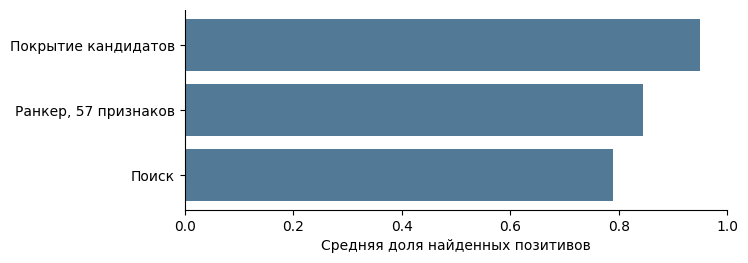

Покрытие кандидатов 0.9498


In [32]:
coverage = []
for i in text_test:
    a, b = text_features["offsets"][i:i + 2]
    gold = set(text_queries.iloc[i].gold)
    found = set(item_ids[text_features["ids"][a:b]])
    coverage.append(len(gold & found) / len(gold))
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(["Поиск", "Ранкер, 57 признаков", "Покрытие кандидатов"],
        [search_scores[text_test].mean(), text_scores["57 признаков"].mean(), np.mean(coverage)], color="#527a96")
ax.set(xlim=(0, 1), xlabel="Средняя доля найденных позитивов")
plt.show()
print(f"Покрытие кандидатов {np.mean(coverage):.4f}")

Часть позитивов отсутствует среди кандидатов. Ниже первые три пропуска на val в порядке запросов. На них можно увидеть ограничения текущего поиска.

In [33]:
missing = []
for i in text_val:
    row = text_queries.iloc[i]
    a, b = text_features["offsets"][i:i + 2]
    found = set(item_ids[text_features["ids"][a:b]])
    for item_id in sorted(set(row.gold) - found):
        missing.append({"запрос": row.search_query, "локация запроса": row.search_location_id,
                        "item_id": item_id})
missing = pd.DataFrame(missing, columns=["запрос", "локация запроса", "item_id"]).merge(
    items[["item_id", "item_title_raw", "item_location_id"]], on="item_id", validate="many_to_one")
missing["та же локация"] = missing["локация запроса"].eq(missing.item_location_id)
print(f"Положительных пар вне кандидатов на val: {len(missing)}")
display(missing[["запрос", "item_title_raw", "та же локация"]].head(3).rename(
    columns={"item_title_raw": "положительное объявление"}))

del text_train, text_features, text_models, text_blocks, arrays, fit_text, core_model, fields_model
_ = gc.collect()

Положительных пар вне кандидатов на val: 60


,запрос,положительное объявление,та же локация
0,3d скульптинг,3d моделирование,False
1,sketch массаж,ручной массаж.аппаратный массаж. массаж лица,False
2,speaking club,разговорный клуб английский для взрослых в1-в2+,True


## Поиск по смыслу

В показанной паре «speaking club» и «разговорный клуб английский» одна услуга названа на разных языках. В двух других примерах различается ещё и локация, так что сводить все пропуски к словам нельзя. Дополнительный поиск по близости векторов может найти объявления без буквального совпадения.

Возьму `multilingual-e5-small` без дообучения. Для CPU начну с короткого входа, до 200 символов заголовка и столько же из параметров, максимум 80 токенов. Описания длиннее и часто содержат перечни услуг. Их добавление и увеличение длины требуют отдельного сравнения, которого здесь пока нет. Использую префиксы `query: ` и `passage: `, среднее по непустым токенам и L2-нормировку.

Предыдущий test уже разобран. Для нового сравнения снова отложу 800 val и 800 test. Текстовый контроль переобучу на тех же запросах.

In [34]:
evaluation, fit, blocks = split_data(train)
final_val = np.flatnonzero(evaluation.split.eq("val"))
final_test = np.flatnonzero(evaluation.split.eq("test"))
previous_texts = set(first.query_norm) | set(geo_queries.query_norm) | set(text_queries.query_norm)
assert not set(evaluation.query_norm) & previous_texts
for q, fitting in blocks:
    assert not set(q.query_norm) & set(fitting.query_norm)
    assert not set(fitting.query_norm) & (previous_texts | set(evaluation.query_norm))
evaluation.groupby("split").agg(запросов=("query_id", "size"))

,запросов
split,
test,800
val,800


In [35]:
pd.DataFrame([
    {"сравнение": name, "val": frame.split.eq("val").sum(), "test": frame.split.eq("test").sum()}
    for name, frame in [("Текстовый поиск", first), ("География", geo_queries),
                        ("Признаки ранкера", text_queries), ("Добавление E5", evaluation)]
]).set_index("сравнение")

,val,test
сравнение,,
Текстовый поиск,800,800
География,800,800
Признаки ранкера,800,800
Добавление E5,800,800


Каждая строка относится к своему набору текстов. Сравнивать модели по абсолютным числам из разных строк нельзя. Для добавления E5 текстовый контроль ниже заново обучается на последнем разбиении.

In [36]:
from src.encoder import embeddings, item_text

semantic_config = {**geo_config, "e5_weight": 0.5, "e5_geo": 0.05, "e5_max_length": 80}
vectors = embeddings(item_text(items), "passage: ", work / "embeddings/local_items.npy",
                     bundle=ROOT / "artifacts/embeddings/local_items.npy", rebuild=REBUILD,
                     max_length=semantic_config["e5_max_length"])
query_vectors = embeddings(evaluation.search_query.map(normalize).tolist(), "query: ",
                           work / "holdout/query_embeddings.npy",
                           bundle=ROOT / "artifacts/holdout/query_embeddings.npy", rebuild=REBUILD,
                           max_length=semantic_config["e5_max_length"])
print("Объявления", vectors.shape, "Запросы", query_vectors.shape)
np.testing.assert_allclose(np.linalg.norm(query_vectors, axis=1), 1, atol=1e-5)

Объявления (515895, 384) Запросы (1600, 384)


Возьму top-500 по косинусу и top-500 по косинусу с поправкой `0.05 * log(географический множитель)`. Объединю их с текстовыми кандидатами. Коэффициент 0.05 и размеры списков оставлю фиксированными.

Сначала посмотрю выдачу для одного запроса напрямую по всем эмбеддингам. При подготовке признаков тот же поиск выполняется блоками.

In [37]:
from src.geography import location_factor

i = 0
geo = GeoModel.fit(fit)
locations = items.item_location_id.to_numpy()
geo_positions = geo.destination_positions(locations)
source = evaluation.iloc[i].search_location_id
cosine = vectors @ query_vectors[i]
factors = location_factor(source, locations, geo_positions, geo, semantic_config, source in set(locations))
nearest = top(cosine + semantic_config["e5_geo"] * np.log(factors), 500)
print(evaluation.iloc[i].search_query)
pd.DataFrame({"объявление": items.iloc[nearest[:5]].item_title_raw.to_numpy(),
              "косинус": cosine[nearest[:5]], "географический множитель": factors[nearest[:5]]})

3 д моделирование и 2д чертежи


,объявление,косинус,географический множитель
0,"3д моделирование и 2д чертежи, создание моделе...",0.871753,135.935699
1,3д моделирование и печать,0.856784,135.935699
2,чертежи на заказ от руки и в компас 3d,0.856228,135.935699
3,"разработка чертежей ескд, 3d моделирование sol...",0.853178,135.935699
4,3d сканирование и моделирование,0.850833,135.935699


In [38]:
control_features = prepare_core(items, evaluation, fit, geo_config, work / "holdout_text",
                                bundle=ROOT / "artifacts/holdout_text", rebuild=REBUILD)
control_features = add_fields(control_features, items, evaluation, rebuild=REBUILD)
eval_features = prepare_core(items, evaluation, fit, semantic_config, work / "holdout",
                             bundle=ROOT / "artifacts/holdout", rebuild=REBUILD, semantic=True,
                             item_vectors=vectors, query_vectors=query_vectors)
eval_features = add_fields(eval_features, items, evaluation, rebuild=REBUILD)
print("Текстовых кандидатов", len(control_features["ids"]))
print("После добавления E5", len(eval_features["ids"]))

Текстовых кандидатов 2733768
После добавления E5 3625166


In [39]:
control_train, e5_train = [], []
for fold, (q, fitting) in enumerate(blocks):
    control = prepare_core(items, q, fitting, geo_config, work / f"training/text_reference/fold{fold}",
                           bundle=ROOT / f"artifacts/training/text_reference/fold{fold}",
                           rebuild=REBUILD, training=True, fold=fold)
    control_train.append(add_fields(control, items, q, rebuild=REBUILD))
    features = prepare_core(items, q, fitting, semantic_config, work / f"training/e5_ranker/fold{fold}",
                            bundle=ROOT / f"artifacts/training/e5_ranker/fold{fold}", rebuild=REBUILD,
                            semantic=True, training=True, fold=fold, item_vectors=vectors)
    e5_train.append(add_fields(features, items, q, rebuild=REBUILD))
del control, features
pd.DataFrame({"обучение": ["Текстовый поиск", "С кандидатами E5"],
              "строк": [sum(len(x["y"]) for x in control_train), sum(len(x["y"]) for x in e5_train)],
              "признаков": [control_train[0]["X"].shape[1], e5_train[0]["X"].shape[1]]})

,обучение,строк,признаков
0,Текстовый поиск,1093677,57
1,С кандидатами E5,1121087,57


In [40]:
models = {}
models["Текстовый ранкер"] = fit_ranker(
    control_train, work / "model/text_57_reference.cbm", ROOT / "model/text_57_reference.cbm",
    {**params, "random_seed": SEED}, train=TRAIN)
control_choice = text_choices.loc["57 признаков"]
control_val, _ = evaluate_ranker(control_features, models["Текстовый ранкер"], evaluation, "val",
                                 int(control_choice["деревьев"]), control_choice["вес"])
print(f"Текстовый контроль на новом val = {control_val.mean():.4f}")
save_choice(models["Текстовый ранкер"], work / "model/text_57_reference.cbm",
            control_choice["деревьев"], control_choice["вес"], geo_config, semantic=False)
del control_train

Текстовый контроль на новом val = 0.8258


Сначала обучу вариант с новыми кандидатами на прежних 57 признаках. E5 уже меняет набор примеров и поисковую оценку для смешивания, её ранг входит с фиксированным весом 0.5. Для текстового контроля сохраняются настройки, выбранные в предыдущей серии.

In [41]:
models["Кандидаты E5, 57 признаков"] = fit_ranker(
    e5_train, work / "model/ranker.cbm", ROOT / "model/ranker.cbm",
    {**params, "random_seed": SEED}, train=TRAIN)
e5_grid = []
for trees, weight in product([100, 250, 500], [0.5, 0.75, 1.0]):
    scores, _ = evaluate_ranker(eval_features, models["Кандидаты E5, 57 признаков"],
                                evaluation, "val", trees, weight)
    e5_grid.append({"модель": "Кандидаты E5, 57 признаков", "деревьев": trees,
                    "вес": weight, "val": scores.mean()})
pd.DataFrame(e5_grid).pivot(index="деревьев", columns="вес", values="val").round(4)

вес,0.50,0.75,1.00
деревьев,,,
100,0.8492,0.8298,0.8067
250,0.8467,0.8248,0.8017
500,0.8483,0.8242,0.7935


Пока ранкер не видит близость векторов напрямую. Добавлю девять столбцов, в том числе косинус, отступ от лучшего совпадения, ранги E5 и присутствие в каналах. Состав кандидатов и обучающие пары оставлю теми же.

In [42]:
from src.pipeline import add_embeddings

eval_features = add_embeddings(eval_features, items, evaluation, fit, semantic_config,
                               rebuild=REBUILD, item_vectors=vectors, query_vectors=query_vectors)
e5_train = [add_embeddings(block, items, q, fitting, semantic_config,
                           rebuild=REBUILD, item_vectors=vectors)
            for block, (q, fitting) in zip(e5_train, blocks)]
assert all(block["X"].shape[1] == 66 for block in e5_train)
models["Кандидаты и признаки E5"] = fit_ranker(
    e5_train, work / "model/e5_features.cbm", ROOT / "model/e5_features.cbm",
    {**params, "random_seed": SEED}, train=TRAIN)
del e5_train
_ = gc.collect()

In [43]:
name = "Кандидаты и признаки E5"
for trees, weight in product([100, 250, 500], [0.5, 0.75, 1.0]):
    values, _ = evaluate_ranker(eval_features, models[name], evaluation, "val", trees, weight)
    e5_grid.append({"модель": name, "деревьев": trees, "вес": weight, "val": values.mean()})
e5_grid = pd.DataFrame(e5_grid)
e5_choices = e5_grid.loc[e5_grid.groupby("модель", sort=False).val.idxmax()].set_index("модель")
selected = e5_grid.loc[e5_grid.val.idxmax()]
display(e5_choices.round(4))
print("Выбрано по val", selected["модель"])

for name, filename in [("Кандидаты E5, 57 признаков", "ranker"),
                       ("Кандидаты и признаки E5", "e5_features")]:
    choice = e5_choices.loc[name]
    save_choice(models[name], work / f"model/{filename}.cbm",
                choice["деревьев"], choice["вес"], semantic_config)

selected_name = selected["модель"]
selected_trees = int(selected["деревьев"])
selected_weight = float(selected["вес"])
selected_dimensions = len(models[selected_name].feature_names_)
model_path = work / "model/answer.cbm"
save_choice(models[selected_name], model_path, selected_trees, selected_weight, semantic_config)

,деревьев,вес,val
модель,,,
"Кандидаты E5, 57 признаков",100,0.5,0.8492
Кандидаты и признаки E5,100,0.5,0.8485


Выбрано по val Кандидаты E5, 57 признаков


In [44]:
final_scores, final_predictions, final_rows = {}, {}, []
for name, model in models.items():
    features = control_features if name == "Текстовый ранкер" else eval_features
    choice = control_choice if name == "Текстовый ранкер" else e5_choices.loc[name]
    pred = predict(features, model, int(choice["деревьев"]), choice["вес"])
    values = measure(pred, evaluation)
    final_scores[name] = {"val": values[final_val], "test": values[final_test]}
    final_predictions[name] = pred
    final_rows.append({"модель": name, "val": values[final_val].mean(), "test": values[final_test].mean()})
final_table = pd.DataFrame(final_rows).set_index("модель")
print("Сравнение добавления E5 на общих запросах")
final_table.round(4)

Сравнение добавления E5 на общих запросах


,val,test
модель,,
Текстовый ранкер,0.8258,0.8244
"Кандидаты E5, 57 признаков",0.8492,0.8452
Кандидаты и признаки E5,0.8485,0.8490


Выбор модели сделан по val до этой таблицы. Более высокий test другого варианта сам по себе не основание менять решение.

,разница,нижняя граница,верхняя граница,лучше,хуже
сравнение,,,,,
Кандидаты E5,0.0208,0.0056,0.0356,29,12
Признаки E5,0.0038,-0.0075,0.0150,12,9


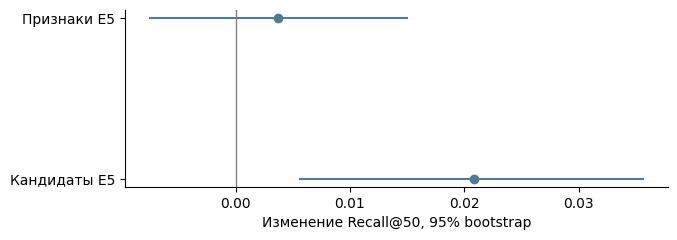

In [45]:
comparisons = []
for left, right in [("Кандидаты E5, 57 признаков", "Текстовый ранкер"),
                    ("Кандидаты и признаки E5", "Кандидаты E5, 57 признаков")]:
    delta = final_scores[left]["test"] - final_scores[right]["test"]
    low, high = bootstrap(delta)
    comparisons.append({"сравнение": "Кандидаты E5" if right == "Текстовый ранкер" else "Признаки E5",
                        "разница": delta.mean(), "нижняя граница": low, "верхняя граница": high,
                        "лучше": (delta > 0).sum(), "хуже": (delta < 0).sum()})
comparison = pd.DataFrame(comparisons).set_index("сравнение")
display(comparison.round(4))
fig, ax = plt.subplots(figsize=(7, 2.3))
for i, (_, row) in enumerate(comparison.iterrows()):
    ax.plot([row["нижняя граница"], row["верхняя граница"]], [i, i], color="#527a96")
    ax.plot(row["разница"], i, "o", color="#527a96")
ax.axvline(0, color="grey", linewidth=1)
ax.set(yticks=range(len(comparison)), yticklabels=comparison.index, xlabel="Изменение Recall@50, 95% bootstrap")
plt.show()

Доверительные интервалы относятся к попарной разнице на этих запросах. Добавление E5 одновременно меняет кандидатов, негативы при обучении и поисковую оценку. Одной итоговой таблицы недостаточно, чтобы разделить их вклад.

In [46]:
restricted = predict(eval_features, models[selected_name], selected_trees, selected_weight,
                     indices=final_test, text_only=True)
restricted_scores = measure(restricted, evaluation.iloc[final_test])
full_scores = final_scores[selected_name]["test"]
delta = full_scores - restricted_scores
low, high = bootstrap(delta)
display(pd.DataFrame({"Recall@50": {"Все кандидаты": full_scores.mean(),
                                   "Только прежние текстовые": restricted_scores.mean()}}).round(4))
pd.Series({"разница": delta.mean(), "нижняя граница": low, "верхняя граница": high,
           "лучше": (delta > 0).sum(), "хуже": (delta < 0).sum()}).round(4)

,Recall@50
Все кандидаты,0.8452
Только прежние текстовые,0.8294


разница             0.0158
нижняя граница      0.0075
верхняя граница     0.0246
лучше              13.0000
хуже                0.0000
dtype: float64

Здесь модель, её оценки и ранги смешивания зафиксированы. Только перед отбором top-50 исключены новые кандидаты E5. Это проверяет пользу дополнительных объявлений при данном ранжировании, но не объясняет весь прирост относительно отдельно обученного текстового контроля.

In [47]:
present = evaluation.iloc[final_test].search_location_id.isin(items.item_location_id).to_numpy()
slice_rows = []
for label, mask in [("Есть в каталоге", present), ("Нет в каталоге", ~present)]:
    text_values = final_scores["Текстовый ранкер"]["test"][mask]
    e5_values = full_scores[mask]
    delta = e5_values - text_values
    low, high = bootstrap(delta)
    slice_rows.append({"локация запроса": label, "запросов": mask.sum(),
                       "текстовый ранкер": text_values.mean(), "с E5": e5_values.mean(),
                       "разница": delta.mean(), "нижняя граница": low, "верхняя граница": high,
                       "лучше": (delta > 0).sum(), "хуже": (delta < 0).sum()})
pd.DataFrame(slice_rows).set_index("локация запроса").round(4)

,запросов,текстовый ранкер,с E5,разница,нижняя граница,верхняя граница,лучше,хуже
локация запроса,,,,,,,,
Есть в каталоге,660,0.8364,0.8684,0.0321,0.0167,0.0492,27,5
Нет в каталоге,140,0.7679,0.7357,-0.0321,-0.0715,0.0071,2,7


В сохранённом запуске на запросах без локации в каталоге средняя разница отрицательна, но её интервал включает ноль. Это ограничение результата. Зависимость веса E5 и географической поправки от такого признака стоит проверять на новом val, не подбирать переключение по этому test.

Оставшиеся ошибки разделю на пропуски поиска и потери при отборе.

In [48]:
predictions = final_predictions[selected_name]
recalls = measure(predictions, evaluation)
actual = final_table.loc[selected_name].to_dict()
del control_features, models
gc.collect()
losses = []
for i in final_test:
    row = evaluation.iloc[i]
    lo, hi = eval_features["offsets"][i:i + 2]
    found = set(item_ids[eval_features["ids"][lo:hi]])
    answer = set(item_ids[predictions[i]])
    gold = set(row.gold)
    losses.append([len(gold - found) / len(gold), len((gold & found) - answer) / len(gold),
                   len(gold & answer) / len(gold)])
losses = pd.DataFrame(losses, columns=["потеря при поиске", "потеря при отборе", "Recall@50"])
np.testing.assert_allclose(losses.sum(axis=1), 1)
np.testing.assert_allclose(losses["Recall@50"].mean(), actual["test"])
losses.mean().round(4)

потеря при поиске    0.0460
потеря при отборе    0.1088
Recall@50            0.8452
dtype: float64

Два случая ниже выбраны после просмотра ошибок и не оценивают частоту причин. Для каждого показаны известные позитивы, несколько ответов и граница top-50. Отсутствие положительной метки у другого объявления не означает, что оно нерелевантно.

In [49]:
from catboost import CatBoostRanker
from src.features import ranks
from src.geography import GeoModel, location_factor

ranker = CatBoostRanker().load_model(str(model_path))
geo = GeoModel.fit(fit)
locations = items.item_location_id.to_numpy()
geo_positions = geo.destination_positions(locations)

cases = ["газовщик сварщик", "машина для выкачки канализации"]
for text in cases:
    matches = evaluation.index[evaluation.search_query.eq(text) & evaluation.split.eq("test")]
    if not len(matches):
        continue
    i = matches[0]
    row = evaluation.loc[i]
    lo, hi = eval_features["offsets"][i:i + 2]
    ids = eval_features["ids"][lo:hi]
    case_X = eval_features["X"][lo:hi, :len(ranker.feature_names_)]
    model_scores = ranker.predict(case_X, ntree_end=selected_trees, thread_count=6)
    model_ranks = ranks(model_scores)
    search_ranks = ranks(eval_features["rrf"][lo:hi])
    final_ranks = ranks(selected_weight / (60 + model_ranks) +
                        (1 - selected_weight) / (60 + search_ranks))
    order = np.argsort(final_ranks)
    np.testing.assert_array_equal(ids[order[:50]], predictions[i])
    gold_ids = np.flatnonzero(items.item_id.isin(row.gold))
    shown = np.unique(np.r_[gold_ids, ids[order[:3]], ids[order[49:51]]])

    print(f"Запрос «{text}». Recall@50 {recalls[i]:.2f}")
    print(f"Локация {row.search_location_id}, категория {row.search_category}, "
          f"доставка {'да' if row.search_is_delivery_search else 'нет'}")
    print("Фильтры", row.search_infm_params_text or "не заданы")
    table = pd.DataFrame({
        "Объявление": items.iloc[ids].item_title_raw.to_numpy(),
        "Позитив": np.isin(item_ids[ids], row.gold),
        "Одна локация": locations[ids] == row.search_location_id,
        "CatBoost": model_scores,
        "RRF поиска": eval_features["rrf"][lo:hi],
        "Ранг модели": model_ranks, "Ранг поиска": search_ranks, "После смешивания": final_ranks,
    }, index=ids).reindex(shown)
    for idx in gold_ids:
        table.loc[idx, ["Объявление", "Позитив", "Одна локация"]] = [
            items.iloc[idx].item_title_raw, True, locations[idx] == row.search_location_id]
    display(table.sort_values("После смешивания").style.hide(axis="index").format({
        "Позитив": lambda x: "да" if x else "нет метки",
        "Одна локация": lambda x: "да" if x else "нет",
        "CatBoost": "{:.3f}", "RRF поиска": "{:.4f}",
        "Ранг модели": "{:.0f}", "Ранг поиска": "{:.0f}", "После смешивания": "{:.0f}",
    }, na_rep="-"))

    cosine = vectors @ query_vectors[i]
    factors = location_factor(row.search_location_id, locations, geo_positions, geo,
                              semantic_config, row.search_location_id in set(locations))
    cosine_ranks = ranks(cosine)
    geo_ranks = ranks(cosine + semantic_config["e5_geo"] * np.log(factors))
    display(pd.DataFrame({
        "Позитив": items.iloc[gold_ids].item_title_raw.to_numpy(),
        "Ранг E5": cosine_ranks[gold_ids], "Ранг E5 с географией": geo_ranks[gold_ids],
        "В кандидаты": ["да" if idx in ids else "нет" for idx in gold_ids],
    }).style.hide(axis="index"))
    for idx in gold_ids:
        if idx not in predictions[i]:
            print("Пропущенное объявление", items.iloc[idx].item_title_raw)
            print("Локация объявления", locations[idx])
            description = items.iloc[idx].item_description_raw
            start, end = ("газоснабжение.", "газоотведение") if text == cases[0] else (
                "откачка промышленных отходов", "производства")
            left = description.find(start)
            left = max(left, 0)
            right = description.find(end, left)
            right = right + len(end) if right >= left else left + 500
            print("Фрагмент описания", description[left:right])
    print()
del ranker, geo

Запрос «газовщик сварщик». Recall@50 0.50
Локация 633540, категория 114, доставка нет
Фильтры Вид услуги Ремонт и обслуживание техники


Объявление,Позитив,Одна локация,CatBoost,RRF поиска,Ранг модели,Ранг поиска,После смешивания
"ремонт газовых котлов, колонок, газовщик",нет метки,да,5.099,0.0403,1,3,1
услуги сварщика,нет метки,да,2.845,0.0411,3,2,2
сварщик. услуги сварщика. сварочные работы,нет метки,да,2.487,0.0414,8,1,3
"сварщик,установщик газовых котлов",да,да,1.829,0.0358,30,9,9
сварка оптоволокна спайка,нет метки,да,0.317,0.0224,166,35,50
сварочные работы автомобили,нет метки,да,0.673,0.0127,112,51,51
газоэлектросварщик,да,да,-0.502,0.0133,306,44,84


Позитив,Ранг E5,Ранг E5 с географией,В кандидаты
"сварщик,установщик газовых котлов",21,1,да
газоэлектросварщик,1067,18,да


Пропущенное объявление газоэлектросварщик
Локация объявления 633540
Фрагмент описания газоснабжение. сварка труб любых диаметров; установка газовых счетчиков, газоотведение

Запрос «машина для выкачки канализации». Recall@50 0.00
Локация 634640, категория 114, доставка нет
Фильтры не заданы


Объявление,Позитив,Одна локация,CatBoost,RRF поиска,Ранг модели,Ранг поиска,После смешивания
"чистка, прочистка канализации. устранить засор",нет метки,да,4.206,0.0429,1,1,1
"прочистка, чистка канализации. устранить засор",нет метки,да,3.758,0.0421,2,2,2
"прочистка канализации, устронение, чистка труб",нет метки,да,3.597,0.0416,3,3,3
"выкачка выгребных ям, канализации",нет метки,нет,1.426,0.0056,35,264,50
вывоз мусора / лодочка/ контейнер 8м3 /мусоровоз,нет метки,да,1.369,0.0068,40,223,51
откачка услуги илососа,да,нет,-,-,-,-,-


Позитив,Ранг E5,Ранг E5 с географией,В кандидаты
откачка услуги илососа,1984,2126,нет


Пропущенное объявление откачка услуги илососа
Локация объявления 634600
Фрагмент описания откачка промышленных отходов производства



В показанном запуске «газоэлектросварщик» попал в кандидаты, но потерял позиции после CatBoost. В описании есть сварка труб и газоснабжение. Совпадение нескольких слов и влияние категории стоит проверить отдельно, таблица сама по себе не устанавливает причину низкой оценки.

Для запроса «машина для выкачки канализации» позитив «откачка услуги илососа» не дошёл до ранкера. Здесь следующими гипотезами будут текст входа E5 и региональный поиск. При другом запуске позиции и попадания нужно читать из таблиц выше.

## Ответ для benchmark

Выбранные веса остаются теми же. Каталог теперь содержит только объявления benchmark, а география и вероятность категории рассчитываются по полному train. Ниже тот же расчёт признаков и отбор top-50, после него получается `answer.csv`.

In [50]:
from src.pipeline import export_answer

del eval_features, items, vectors, query_vectors, blocks, features
_ = gc.collect()
benchmark_items = corpus(benchmark=True)
if REBUILD:
    benchmark_vectors = embeddings(item_text(benchmark_items), "passage: ",
                                    work / "embeddings/benchmark_items.npy",
                                    max_length=semantic_config["e5_max_length"])
    benchmark_queries = embeddings(queries.search_query.map(normalize).tolist(), "query: ",
                                   work / "benchmark/query_embeddings.npy",
                                   max_length=semantic_config["e5_max_length"])
else:
    benchmark_vectors = benchmark_queries = None
benchmark_features = prepare_core(
    benchmark_items, queries, train, semantic_config, work / "benchmark",
    bundle=ROOT / "artifacts/benchmark", rebuild=REBUILD, semantic=True, tag="benchmark",
    item_vectors=benchmark_vectors, query_vectors=benchmark_queries)
benchmark_features = add_fields(benchmark_features, benchmark_items, queries,
                                 rebuild=REBUILD, tag="benchmark")
if selected_dimensions == 66:
    benchmark_features = add_embeddings(
        benchmark_features, benchmark_items, queries, train, semantic_config, rebuild=REBUILD,
        item_vectors=benchmark_vectors, query_vectors=benchmark_queries, tag="benchmark")
answer = export_answer(queries, benchmark_items,
                       predict(benchmark_features, model_path), ROOT / "answer.csv")
print(f"answer.csv, {answer['rows']} строк по 50 объявлений")
print(f"Выбран {selected_name}, {selected_trees} деревьев, вес {selected_weight}")
print(f"Локальный test {actual['test']:.4f}, текстовый контроль {final_table.loc['Текстовый ранкер', 'test']:.4f}")

answer.csv, 2452 строк по 50 объявлений
Выбран Кандидаты E5, 57 признаков, 100 деревьев, вес 0.5
Локальный test 0.8452, текстовый контроль 0.8244


Разметка содержит только известные положительные пары. Локальный holdout проверяет новые формулировки и использует более широкий каталог, часть текстов benchmark уже встречалась в train. Поэтому локальный Recall не предсказывает скрытый тест. Для следующих экспериментов нужен новый holdout, этот test уже разобран.

[multilingual-e5-small](https://huggingface.co/intfloat/multilingual-e5-small) используется без дообучения.